In [31]:
from PIL import Image
import requests
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor,AutoModel

In [32]:
# model_path = "/home/siamai/data/models/models--scb10x--typhoon2-qwen2vl-7b-vision-instruct/snapshots/04855386c8e492daf756968ac9b2621dcca46afa"

# model = Qwen2VLForConditionalGeneration.from_pretrained(
#     model_path, torch_dtype="auto", device_map="auto"
# )
# processor = AutoProcessor.from_pretrained(model_path)

In [33]:
import glob
from pathlib import Path

test_dir = Path("/home/siamai/data/Focus/LV1/ImageCaptioning/test/test/")
files = glob.glob(pathname = "/home/siamai/data/Focus/LV1/ImageCaptioning/train/train/travel/*")
files.extend(glob.glob(pathname = "/home/siamai/data/Focus/LV1/ImageCaptioning/train/train/food/*"))

# FineTune QwenVL

In [34]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

In [35]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2025.6.2: Fast Qwen2_5_Vl patching. Transformers: 4.52.4.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [36]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 32,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [37]:
from datasets import load_dataset
dataset = load_dataset("NatthasitW/ImageCaptioning", split = "train")

In [38]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 28004
})

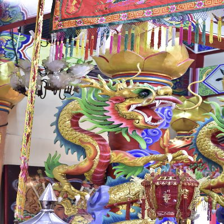

In [39]:
dataset[0]["image"]

In [40]:
dataset[0]["text"]

'รูปปั้นพญานาคตัวสีทองมีดอกบัวอยู่ด้านข้างอยู่ใกล้กับเสาสีแดง'

In [41]:
instruction = "จงอธิบายรูปภาพนี้เป็นภาษาไทย"

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [42]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [43]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text', 'text': 'จงอธิบายรูปภาพนี้เป็นภาษาไทย'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=224x224>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'รูปปั้นพญานาคตัวสีทองมีดอกบัวอยู่ด้านข้างอยู่ใกล้กับเสาสีแดง'}]}]}

รูปภาพนี้แสดงพื้นที่ภายในวัดหรือสำนักสงฆ์ มองเห็นการตกแต่งด้วยลายเส้นสีฟ้าและสีแดงอย่างประณีตบนกำแพงและดวงไฟส่องแสงในตัว


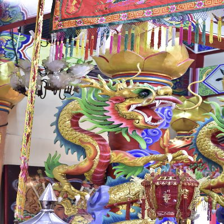

In [44]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "จงอธิบายรูปภาพนี้เป็นภาษาไทย"

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 64,
                   use_cache = True, temperature = 1.5, min_p = 0.1)
image.show()

In [45]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 128,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 2, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        dataset_num_proc = 4,
        max_seq_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [46]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 28,004 | Num Epochs = 2 | Total steps = 110
O^O/ \_/ \    Batch size per device = 128 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (128 x 4 x 1) = 512
 "-____-"     Trainable parameters = 80,740,352/7,000,000,000 (1.15% trained)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
1,5.024100
2,5.020100
3,5.030400
4,4.874700
5,4.270300
6,3.375500
7,2.645100
8,2.311800
9,1.989900
10,1.706700


## Batch Inference

In [47]:
from torch.utils.data import Dataset,DataLoader
from tqdm import tqdm
import pandas as pd

รูปปั้นพญานาคสีทองตัวหนึ่งมีกำแพงสีแดงด้านข้าง<|im_end|>


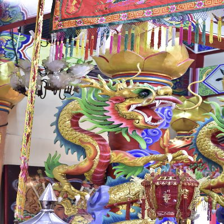

In [48]:
conversation = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(conversation, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
output = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 0.2, min_p = 0.1)
image.show()

In [49]:
text = tokenizer.decode(output[0], skip_special_tokens=True)
thai_text = text.split('assistant\n')[-1].strip()
print(thai_text)  # Output: รูปปั้นพญานาคสีสันสดใสที่มีลวดลายสวยงาม

รูปปั้นพญานาคสีทองตัวหนึ่งมีกำแพงสีแดงด้านข้าง


In [50]:
from pathlib import Path
import glob
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch

In [51]:
class VisionLanguageDataset(Dataset):
    def __init__(self, test_dir, tokenizer,instruction):
        self.test_dir = Path(test_dir)
        # Correct glob usage to get all image files in test_dir
        self.image_paths = glob.glob(str(self.test_dir / "*"))
        self.tokenizer = tokenizer
        self.conversation = [
                {"role": "user", "content": [
                    {"type": "image"},
                    {"type": "text", "text": instruction}
                ]}
                ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path)
        image = image.resize((224, 224))

        input_text = self.tokenizer.apply_chat_template(self.conversation, add_generation_prompt = True)
        inputs = self.tokenizer(
            image,
            input_text,
            add_special_tokens = False,
            return_tensors = "pt",
        )
        # Remove batch dimension from inputs
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        # Return image file stem for tracking
        return inputs,image_path

In [52]:
test_ds = VisionLanguageDataset(test_dir, tokenizer, instruction)
test_dl = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
)

In [53]:
# Initialize answers dictionary
answers = {"image_id": [], "caption": []}

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Batch inference loop
with torch.no_grad():
    for batch_inputs, image_stems in tqdm(test_dl):
        # Move inputs to device
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
        
        # Generate outputs
        outputs = model.generate(**batch_inputs, 
                                    max_new_tokens = 128,
                                    use_cache = True)
        
        decoded_outputs = [tokenizer.decode(output, skip_special_tokens=True).split('assistant\n')[-1].strip() for output in outputs]
        # Append results to answers
        answers["image_id"].extend(image_stems)
        answers["caption"].extend(decoded_outputs)

# Example: Print results
for img_id, caption in zip(answers["image_id"], answers["caption"]):
    print(f"Image: {img_id}, Caption: {caption}")

  0%|          | 0/63 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true

100%|██████████| 63/63 [03:55<00:00,  3.74s/it]


Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/00024.jpg, Caption: แม่น้ำที่มีผืนไม้และภูเขาด้านข้าง มีต้นไม้สีเขียวอยู่ด้านบน
Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/00751.jpg, Caption: หินสีเทาที่มีตะไคร่น้ำและหญ้าติดอยู่บนผิวหิน
Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/00279.jpg, Caption: ขนมสีน้ำตาลที่มีผงช็อกโกแลตโรยอยู่บนโต๊ะสีขาว
Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/01233.jpg, Caption: ดอกไม้สีขาวที่มีลักษณะคล้ายกับหินตั้งอยู่บนพื้นสีชมพู
Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/01499.jpg, Caption: ผู้ชายใส่เสื้อสีขาวและกางเกงสีดำกำลังเดินอยู่บนถนนด้านข้างมีต้นไม้
Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/01344.jpg, Caption: ผู้ชายสวมเสื้อสีดำกำลังยืนอยู่บนราวไม้ด้านข้างมีต้นไม้อยู่
Image: /home/siamai/data/Focus/LV1/ImageCaptioning/test/test/00670.jpg, Caption: รูปปั้นของสัตว์ที่มีลำตัวสีขาวและมีลายสีดำอยู่บนผนังสีน้ำตาล
Image: /home/siamai/data/Focus/LV1/ImageC

In [54]:
submission = pd.DataFrame(answers)
submission.head()

,image_id,caption
0,/home/siamai/data/Focus/LV1/ImageCaptioning/te...,แม่น้ำที่มีผืนไม้และภูเขาด้านข้าง มีต้นไม้สีเข...
1,/home/siamai/data/Focus/LV1/ImageCaptioning/te...,หินสีเทาที่มีตะไคร่น้ำและหญ้าติดอยู่บนผิวหิน
2,/home/siamai/data/Focus/LV1/ImageCaptioning/te...,ขนมสีน้ำตาลที่มีผงช็อกโกแลตโรยอยู่บนโต๊ะสีขาว
3,/home/siamai/data/Focus/LV1/ImageCaptioning/te...,ดอกไม้สีขาวที่มีลักษณะคล้ายกับหินตั้งอยู่บนพื้...
4,/home/siamai/data/Focus/LV1/ImageCaptioning/te...,ผู้ชายใส่เสื้อสีขาวและกางเกงสีดำกำลังเดินอยู่บ...


In [55]:
import re

def clean_text(text):
    text = re.sub(r"ภาพ", "", text)
    text = re.sub(r"นี้", "", text)
    text = re.sub(r"แสดง", "", text)
    text = re.sub(r"ถึง", "", text)
    return text

def clean_path(path):
    path = Path(path).stem
    return path
submission["caption"] = submission["caption"].apply(clean_text)
submission["image_id"] = submission["image_id"].apply(clean_path)
submission.to_csv("submission.csv",index=False)
submission

,image_id,caption
0,00024,แม่น้ำที่มีผืนไม้และภูเขาด้านข้าง มีต้นไม้สีเข...
1,00751,หินสีเทาที่มีตะไคร่น้ำและหญ้าติดอยู่บนผิวหิน
2,00279,ขนมสีน้ำตาลที่มีผงช็อกโกแลตโรยอยู่บนโต๊ะสีขาว
3,01233,ดอกไม้สีขาวที่มีลักษณะคล้ายกับหินตั้งอยู่บนพื้...
4,01499,ผู้ชายใส่เสื้อสีขาวและกางเกงสีดำกำลังเดินอยู่บ...
...,...,...
1995,01911,ใบตองมีน้ำ滴อยู่บนใบสีเขียวมีขอบสีเหลืองด้านข้า...
1996,00431,ขนมที่มีหลายชนิดอยู่ในจานสีขาวมีถั่วแดงและไข่ม...
1997,00977,ถ้ำที่มีทางเดินสีเทาด้านข้างมีต้นไม้และพืชผัก
1998,00868,ถ้วยพลาสติกใส่เครื่องแกงพร้อมผักชีและพริกสด


In [56]:
!kaggle competitions submit -c "image-processing-thai-language-image-captioning" -f "submission.csv" -m "Zero shot TyphoonVL Improve prompt"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


100%|█████████████████████████████████████████| 334k/334k [00:01<00:00, 206kB/s]
Successfully submitted to Image Processing: Thai Language Image Captioning